This is a preliminary test of getting ahold of stock price data, potentially as some kind of response variable to a stok prediction model. Ultimately, this functionality is out of scope for a purely NLP solution

In [2]:
import yfinance as yf
import pandas as pd
import ast
from requests import Session
from requests_cache import CacheMixin, SQLiteCache
from requests_ratelimiter import LimiterMixin, MemoryQueueBucket
from pyrate_limiter import Duration, RequestRate, Limiter


articles_df = pd.read_csv('../data/article_scraped_data.csv', converters={'stock_codes': ast.literal_eval}).dropna(subset=['document'])
articles_df = articles_df[articles_df['stock_codes'].apply(lambda x: len(x) > 0)]
articles_df.dropna(subset=['document'], inplace=True)
articles_df


,title,author,date_string,sector,stock_codes,document,url,stock_code_industries,stock_code_industry,datetime
0,GreenHy2 secures H2Core deal to advance superc...,Colin Hay,"March 21, 2025",Energy,[ASX:H2G],Solid state hydrogen storage developer GreenHy...,https://smallcaps.com.au/greenhy2-h2core-deal-...,{'Commercial & Professional Services'},Commercial Services,2025-03-21
1,Compumedics reaches $20m in Chinese MEG sales ...,Colin Hay,"March 21, 2025",Biotech,[ASX:CMP],Brain research technologies specialist Compume...,https://smallcaps.com.au/compumedics-chinese-m...,{'Health Care Equipment & Services'},Medical Equipment & Services,2025-03-21
2,CZR Resources receives $75m offer for Robe Mes...,Colin Hay,"March 21, 2025",Mining,[ASX:CZR],CZR Resources (ASX: CZR) has received a condit...,https://smallcaps.com.au/czr-resources-offer-r...,{'Materials'},Materials,2025-03-21
3,Arafura signs five-year offtake deal with Trax...,Colin Hay,"March 20, 2025",Mining,[ASX:ARU],Arafura Rare Earths (ASX: ARU) has signed a bi...,https://smallcaps.com.au/arafura-five-year-off...,{'Materials'},Materials,2025-03-20
4,International Graphite confirms strong economi...,Colin Hay,"March 20, 2025",Mining,[ASX:IG6],International Graphite (ASX: IG6) has received...,https://smallcaps.com.au/international-graphit...,{'Capital Goods'},Capital Goods,2025-03-20
...,...,...,...,...,...,...,...,...,...,...
1527,Mitre Mining scores lithium and rare earths fi...,Colin Hay,"December 18, 2023",Mining,[ASX:MMC],Mitre Mining (ASX: MMC) has hit the daily doub...,https://smallcaps.com.au/mitre-mining-lithium-...,NaN,NaN,2023-12-18
1528,Tamboran Resources joins US energy services ex...,Colin Hay,"December 15, 2023",Energy,[ASX:TBN],Tamboran Resources (ASX: TBN) has reached a st...,https://smallcaps.com.au/tamboran-resources-us...,{'Energy'},Energy,2023-12-15
1529,West Cobar Metals drills up potential large co...,Colin Hay,"December 15, 2023",Mining,[ASX:WC1],West Cobar Metals (ASX: WC1) has continued its...,https://smallcaps.com.au/west-cobar-metals-dri...,{'Materials'},Materials,2023-12-15
1530,Akora Resources moves to pre-feasibility study...,Colin Hay,"December 14, 2023",Mining,[ASX:AKO],Akora Resources (ASX: AKO) has taken a key ste...,https://smallcaps.com.au/akora-resources-pre-f...,{'Materials'},Materials,2023-12-14


In [3]:
stock_codes = articles_df['stock_codes'].explode().unique()
stock_codes # in the format ASX:ABC, need to convert to ABC.AX

def change_stock_string_format(stock_code):
    if stock_code.startswith('ASX:'):
        return stock_code[4:] + '.AX'
    return stock_code

stock_codes = [change_stock_string_format(stock_code) for stock_code in stock_codes]
stock_codes

['H2G.AX',
 'CMP.AX',
 'CZR.AX',
 'ARU.AX',
 'IG6.AX',
 'EL8.AX',
 'T92.AX',
 'WDS.AX',
 'RML.AX',
 'EQR.AX',
 'EMV.AX',
 'ICE.AX',
 'AXL.AX',
 'AII.AX',
 'OCC.AX',
 'AVM.AX',
 'DVL.AX',
 'GRL.AX',
 'NOR.AX',
 'NGI.AX',
 'DNA.AX',
 'VEN.AX',
 'MPK.AX',
 'TMB.AX',
 'ATC.AX',
 'RLT.AX',
 'BOE.AX',
 'PIQ.AX',
 'GRE.AX',
 'LAM.AX',
 'NTU.AX',
 'REE.AX',
 'OVT.AX',
 'BGD.AX',
 'MGU.AX',
 'PHO.AX',
 'PNT.AX',
 'BLG.AX',
 'AEV.AX',
 'NMG.AX',
 'BHM.AX',
 'CBH.AX',
 'EPM.AX',
 'WAF.AX',
 'PTR.AX',
 'HGO.AX',
 'TG6.AX',
 'DEL.AX',
 'RTG.AX',
 'IXU.AX',
 'CU6.AX',
 'ENL.AX',
 'BSX.AX',
 'RGT.AX',
 'LMS.AX',
 'RC1.AX',
 'EGR.AX',
 'IFG.AX',
 'PMT.AX',
 'FFF.AX',
 'AVE.AX',
 'PEB.AX',
 'GG8.AX',
 'FEX.AX',
 'APE.AX',
 'GAP.AX',
 'MAT.AX',
 'BBT.AX',
 'PBH.AX',
 'OLY.AX',
 'LYC.AX',
 'CMB.AX',
 'LDR.AX',
 'CSX.AX',
 'WOA.AX',
 'EVS.AX',
 'EME.AX',
 'AKO.AX',
 'NRX.AX',
 'NVQ.AX',
 'MEU.AX',
 'AWJ.AX',
 'AGR.AX',
 'C1X.AX',
 'VUL.AX',
 'MYX.AX',
 'DHG.AX',
 'WNX.AX',
 'ALC.AX',
 'HMY.AX',
 'MYS.AX',

In [ ]:
import yfinance as yf
from requests_cache import SQLiteCache
from requests_ratelimiter import LimiterMixin, MemoryQueueBucket
from pyrate_limiter import Duration, RequestRate, Limiter
from requests import Session
import pandas as pd

# Define a custom session class for caching and rate limiting
class CachedLimiterSession(LimiterMixin, Session):
    pass

# Initialize the session with caching and rate limiting
session = CachedLimiterSession(
    limiter=Limiter(RequestRate(2, Duration.SECOND * 5)),  # max 2 requests per 5 seconds
    bucket_class=MemoryQueueBucket,
    backend=SQLiteCache("yfinance.cache"),
)

# --- Tickers and dates ---
stock_codes = ['BHP.AX', 'RIO.AX']
start_date = '2024-01-01'
end_date = '2025-03-31'
# --- Download all tickers at once ---
df = yf.download(stock_codes, start=start_date, end=end_date, period='1d', group_by='ticker', session=session)

# Combine all tickers into one DataFrame
df


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  2 of 2 completed


Ticker         BHP.AX                                                RIO.AX  \
Price            Open       High        Low      Close   Volume        Open   
Date                                                                          
2024-01-02  46.582882  47.024270  46.555002  46.963871  3375905  123.825571   
2024-01-03  46.647926  46.685097  46.201891  46.248352  4483073  124.366340   
2024-01-04  46.592169  46.592169  46.071796  46.071796  4458375  123.174822   
2024-01-05  45.904533  46.071796  45.551420  45.597881  3992737  123.284803   
2024-01-08  45.644346  45.760502  45.086803  45.216896  3513478  121.213410   
...               ...        ...        ...        ...      ...         ...   
2025-03-24  39.220001  39.389999  38.980000  39.320000  4818118  117.989998   
2025-03-25  39.209999  39.380001  38.970001  39.040001  6558976  118.959999   
2025-03-26  39.549999  39.889999  39.450001  39.520000  8633420  120.129997   
2025-03-27  39.500000  39.740002  39.360001  39.639999  7659354  119.879997   
2025-03-28  39.599998  40.119999  39.459999  39.689999  8680085  119.760002   

Ticker                                                   
Price             High         Low       Close   Volume  
Date                                                     
2024-01-02  125.314961  123.743072  125.172897   432987  
2024-01-03  124.467160  123.211481  123.477287   687039  
2024-01-04  123.917223  122.876946  123.275642   984237  
2024-01-05  123.321473  121.158420  121.314232   682934  
2024-01-08  122.340760  119.902754  120.544334   785847  
...                ...         ...         ...      ...  
2025-03-24  119.250000  117.739998  119.099998   905575  
2025-03-25  119.820000  118.500000  118.779999   814438  
2025-03-26  121.650002  119.919998  119.959999  1395759  
2025-03-27  120.760002  119.830002  120.089996   924832  
2025-03-28  121.559998  119.239998  121.260002  1253769  

[315 rows x 10 columns]

In [87]:
df.loc['2024-03-01', 'BHP.AX']

Price
Open      4.095167e+01
High      4.183445e+01
Low       4.095167e+01
Close     4.174153e+01
Volume    8.051335e+06
Name: 2024-03-01 00:00:00, dtype: float64

In [ ]:

# Combine into one DataFrame
df = pd.concat(df_list)
df.reset_index(inplace=True)  # Ensure Date is a column, not an index
df = df[['Date', 'ticker', 'Close']]  # Reorder columns

# Save and preview
df.to_csv('ticker.csv', index=False)
print(df.head())


In [33]:
df

Price        Date ticker       Close            
Ticker                          AAPL        MSFT
0      2024-01-02   AAPL  184.532089         NaN
1      2024-01-03   AAPL  183.150391         NaN
2      2024-01-04   AAPL  180.824356         NaN
3      2024-01-05   AAPL  180.098694         NaN
4      2024-01-08   AAPL  184.452576         NaN
..            ...    ...         ...         ...
617    2025-03-24   MSFT         NaN  393.079987
618    2025-03-25   MSFT         NaN  395.160004
619    2025-03-26   MSFT         NaN  389.970001
620    2025-03-27   MSFT         NaN  390.579987
621    2025-03-28   MSFT         NaN  378.799988

[622 rows x 4 columns]

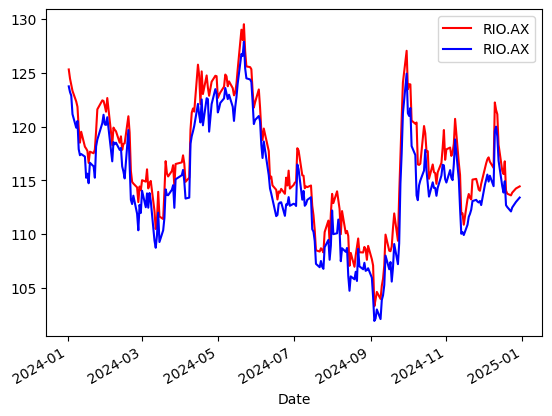

In [3]:
import matplotlib.pyplot as plt
#plot the low as blue and the high as red 
#('High', 'RIO.AX')
#('Low', 'RIO.AX')
fig, ax = plt.subplots()
df['High'].plot(color='red', label='High', ax=ax)
df['Low'].plot(color='blue', label='Low', ax=ax)
plt.legend()
plt.show()



In [4]:

# data.to_csv("RIO_2024_prices.csv")

# Print the first few rows to check
print(data.head())


Price            Close        High         Low        Open  Volume
Ticker          RIO.AX      RIO.AX      RIO.AX      RIO.AX  RIO.AX
Date                                                              
2024-01-02  125.172913  125.314976  123.743087  123.825587  432987
2024-01-03  123.477287  124.467160  123.211481  124.366340  687039
2024-01-04  123.275642  123.917223  122.876946  123.174822  984237
2024-01-05  121.314240  123.321481  121.158428  123.284811  682934
2024-01-08  120.544334  122.340760  119.902754  121.213410  785847
